In [7]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

In [8]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
base_dir = path.join('..', 'results', 'causal_skills_tests')
pattern = path.join(base_dir, '**', 'pareto_fitness.txt')
files = glob(pattern, recursive=True)

records = []
for fp in files:
    df = pd.read_csv(fp, sep='\t', header=None, names=['generation', 'fitness_class'])
    df[['fitness', 'class']] = pd.DataFrame(
        df['fitness_class'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        ).tolist(),
        index=df.index,
    )
    df['run'] = path.basename(path.dirname(fp))
    records.append(df[['generation', 'fitness', 'class', 'run']])

if records:
    pareto_fitness = pd.concat(records, ignore_index=True)
else:
    pareto_fitness = pd.DataFrame(columns=['generation', 'fitness', 'class', 'run'])

# Aggregate mean/std per generation and class
pareto_stats = (
    pareto_fitness
    .groupby(['generation', 'class'])['fitness']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'fitness_mean', 'std': 'fitness_std', 'count': 'n'})
)
pareto_stats['fitness_std'] = pareto_stats['fitness_std'].fillna(0)

print(f"Found {len(files)} pareto_fitness.txt files")
print(pareto_stats.head())
print(f"\nGenerations: {pareto_stats['generation'].min() if not pareto_stats.empty else 'NA'} to {pareto_stats['generation'].max() if not pareto_stats.empty else 'NA'}")

Found 1 pareto_fitness.txt files
   generation  class  fitness_mean  fitness_std  n
0           0     -2 -4.767860e+01          0.0  1
1           0      0 -2.000961e+06          0.0  1
2           1     -2 -4.767860e+01          0.0  2
3           1     -1 -7.666922e+01          0.0  1
4           1      0 -2.000961e+06          0.0  1

Generations: 0 to 300


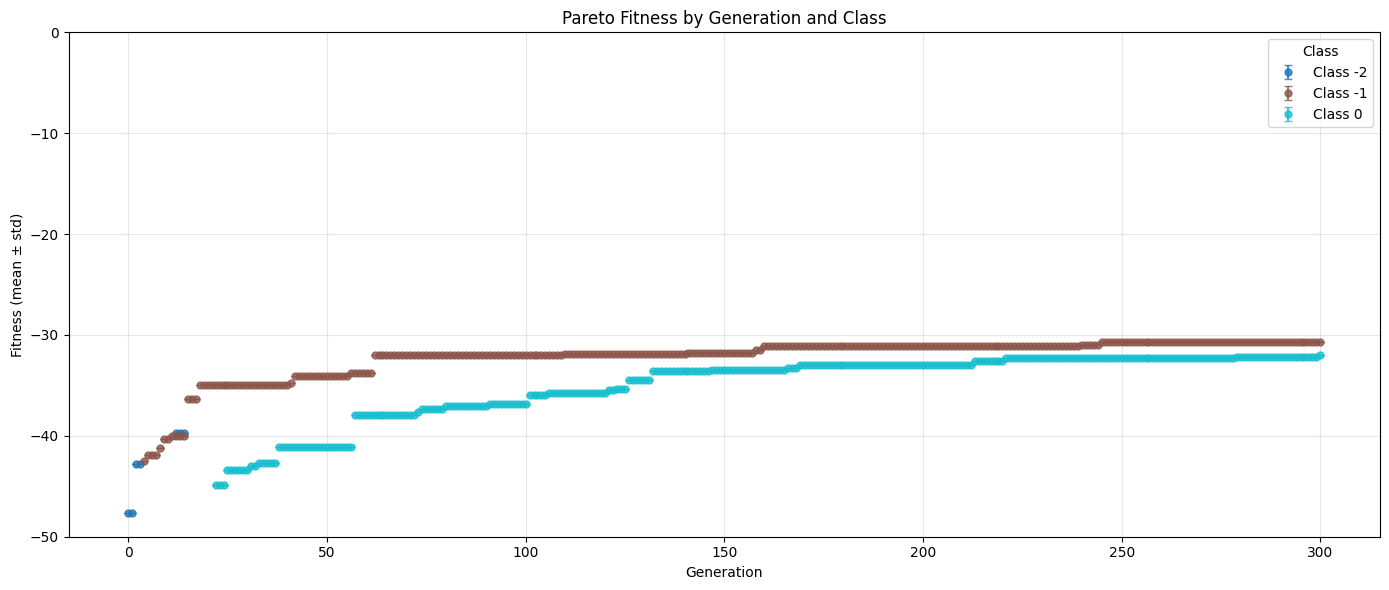

In [10]:
# Plot fitness (mean ± std) vs generation with colors corresponding to class
if pareto_stats.empty:
    print("No data to plot: no pareto_fitness.txt files found.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))

    classes = sorted(pareto_stats['class'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    color_map = {cls: colors[i] for i, cls in enumerate(classes)}

    for cls in classes:
        cls_df = pareto_stats[pareto_stats['class'] == cls]
        ax.errorbar(
            cls_df['generation'],
            cls_df['fitness_mean'],
            yerr=cls_df['fitness_std'],
            fmt='o',
            label=f'Class {cls}',
            alpha=0.8,
            markersize=5,
            color=color_map[cls],
            capsize=3,
            linestyle='None',
        )

    ax.set_xlabel('Generation')
    ax.set_ylabel('Fitness (mean ± std)')
    ax.set_title('Pareto Fitness by Generation and Class')
    ax.legend(title='Class')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-50, 0])
    plt.tight_layout()
    plt.show()